In [14]:
import math
import pandas as pd
import numpy as np
from scipy.stats import norm
import scipy.stats as stats
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


## 1. Объем выборки

Необходимо зафиксировать увеличение CTR=clicks/views на 10% при alpha=0.05 и beta=0.2

### 1.1. Дельта-метод

среднее кликов $ \sim N(\mu_c, \delta^2_c)$, среднее показов $ \sim N(\mu_v, \delta^2_v)$.

CTR = R $ \sim N(\mu_R, \delta^2_R)$. Аппроксимация:
$ \mu_R\approx \mu_c/\mu_v$, $\delta^2_R\approx \frac{\mu^2_c}{\mu^2_v}(\frac{\delta^2_c}{\mu^2_c}+\frac{\delta^2_v}{\mu^2_v}-2\frac{\delta_cv}{\mu_c\mu_v})=\tau$.

t-test для Ratio:
$t=\frac{R_{test}-R_{control}}{\sqrt{\frac{\delta^2_{Rt}}{n_t}+\frac{\delta^2_{Rc}}{n_c}}}$, предполагая равенство дисперсии в контрольной и тестовой группе: $t=\frac{R_t-R_c}{\sqrt{\frac{\tau}{n_t}+\frac{\tau}{n_c}}}$. Положим $n_t=r\cdot n_c$:
$R_t-R_c=t\cdot \sqrt{\frac{1+r}{r} \cdot \frac{\tau}{n_c}}$

Гипотеза $H_0:\mu_{Rc}- \mu_{Rt}=0$,
$C=0+Z_{1-\frac{\alpha}{2}} \cdot \sqrt{\frac{1+r}{r} \cdot \frac{\tau}{n_c}}$

Гипотеза $H_1$: $\mu_{Rc}- \mu_{Rt}=\Delta$,
$C=\Delta-Z_{1-\beta} \cdot \sqrt{\frac{1+r}{r} \cdot \frac{\tau}{n_c}}$

При равенстве критических точек:

$n_c=\frac{1+r}{r} \cdot \frac{\tau \cdot (Z_{1-\frac{\alpha}{2}}+Z_{1-\beta})^2}{\Delta^2}$


In [15]:
# Функция расчета объема выборки для контрольной группы
def calculate_sample_size(c_mean, v_mean, c_var, v_var, cov, alpha=0.05, power=0.8, r=(1/9), rel_mde=0.1):

    tau = ((c_mean**2)/(v_mean**2)) * (c_var/(c_mean**2) + v_var/(v_mean**2) - 2*cov/(c_mean*v_mean))
    z_alpha = norm.ppf(1 - alpha/2)
    z_power = norm.ppf(power)
    delta = rel_mde * (c_mean / v_mean)

    n_control = math.ceil(((1 + r) / r) * tau * ((z_alpha + z_power)**2) / (delta**2))

    return n_control

# загрузка исторических данных до АБ
df = pd.read_csv('history_control.csv')

# агрегация метрик на уровне пользователя
user_data = df.groupby('user_id').agg(
    total_clicks=('clicks', 'sum'),
    total_views=('views', 'sum')
).reset_index()

c_mean = user_data['total_clicks'].mean()
v_mean = user_data['total_views'].mean()

c_var = user_data['total_clicks'].var()
v_var = user_data['total_views'].var()

cov = user_data['total_clicks'].cov(user_data['total_views'])

# задаем долю тестовой группы относительно контрольной
ratio = 1/9

n_control = calculate_sample_size(c_mean, v_mean, c_var, v_var, cov, alpha=0.05, power=0.8, r=ratio, rel_mde=0.1)
n_test = math.ceil(n_control * ratio)

print(f'В контрольной группе требуется выборка размером {n_control}')
print(f'В тестовой группе требуется выборка размером {n_test}')
print(f'Итого требуется выборка общим размером {n_control + n_test}')

В контрольной группе требуется выборка размером 2901
В тестовой группе требуется выборка размером 323
Итого требуется выборка общим размером 3224


Получились достаточно маленькие размеры выборок для проведения теста. Так получилось из-за того, что данные сильно скоррелированы, поэтому корректировка ковариацией сильно снижает дисперсию метрики:

In [16]:
print(f'Среднее число кликов - {c_mean:.2}, среднее число показов - {v_mean:.2}')
print(f'CTR по историческим данным = {c_mean/v_mean:.4}')
print(f'Значения дисперсий кликов, показов и их ковариация: {round(c_var,2), round(v_var,2), round(cov,2)}')

Среднее число кликов - 2.7, среднее число показов - 8.9
CTR по историческим данным = 0.3004
Значения дисперсий кликов, показов и их ковариация: (45.43, 475.72, np.float64(142.7))


### 1.2. Линеаризация

Расчет размера выборки производится для линеаризованной метрики (с использованием дисперсии линеаризованной метрики и линеаризованного MDE), т.е.:

$n_c=\frac{1+r}{r} \cdot \frac{\delta^2 \cdot (Z_{1-\frac{\alpha}{2}}+Z_{1-\beta})^2}{\Delta^2}$, где

$\delta^2$ - дисперсия линеаризованной метрики, $\Delta$ - линеаризованный MDE.

Линеаризованная метрика:

$lc=c-R \cdot v$, где $R=\frac{\sum^N_i{c}}{\sum^N_i{v}}$


In [17]:
ratio = 1/9
rel_mde = 0.1

# расчет поюзерной линеаризованной метрики
user_data['lin_clicks'] = user_data['total_clicks'] - (c_mean/v_mean) * user_data['total_views']

lc_var = user_data['lin_clicks'].var()
lc_mde = rel_mde * c_mean

z_alpha = norm.ppf(1 - 0.05/2)
z_power = norm.ppf(0.8)

n_control = math.ceil(((1 + ratio) / ratio) * lc_var * ((z_alpha + z_power)**2) / (lc_mde**2))
n_test = math.ceil(n_control * ratio)

print(f'В контрольной группе требуется выборка размером {n_control}')
print(f'В тестовой группе требуется выборка размером {n_test}')
print(f'Итого требуется выборка общим размером {n_control + n_test}')

В контрольной группе требуется выборка размером 2901
В тестовой группе требуется выборка размером 323
Итого требуется выборка общим размером 3224


Получился тот же самый результат, поскольку линеаризация использует тот же самый механизм разложения функции в ряд тейлора (до первого линейного элемента). Вероятно, дельта-метод удобно использовать, когда есть исторические данные уже по ratio-метрикам, а линеаризацию - когда есть исходные данные отдельно по метрикам в числителе и знаменателе (кажется, линеаризацию делать технически проще).

### 1.3. Бутстрап

Расчет необходимого размера выборки производится через симуляции Монте-Карло.

1. Симуляции проводятся для разных размеров выборки (берем n от 1000 до 5000 с шагом 500)
2. Берется случайная выборка размера n из исторических данных

    2.1. Случайное сплитование пользователей в контрольную и тестовую группу (в контроль попадает 90%)

    2.2. Добавляем эффект в тестовую группу: для увеличения CTR на 10% умножаем количество кликов у пользователя на 1,1

    2.3. Пуассоновский бутстрап
      
      - перевзвешиваем выборки 1000 раз
      - строим доверительный интервал для разницы средних между группами на основе этих 1000 "выборок"
      - успешный тест: нижняя граница интервала больше 0

3. По итогам проведения (например) 1000 симуляций рассчитываем статистическую мощность = успешные тесты / всего тестов
4. Для каждой n получили статистическую мощность - строим график, оцениваем, при какой n мощность становится более 80%

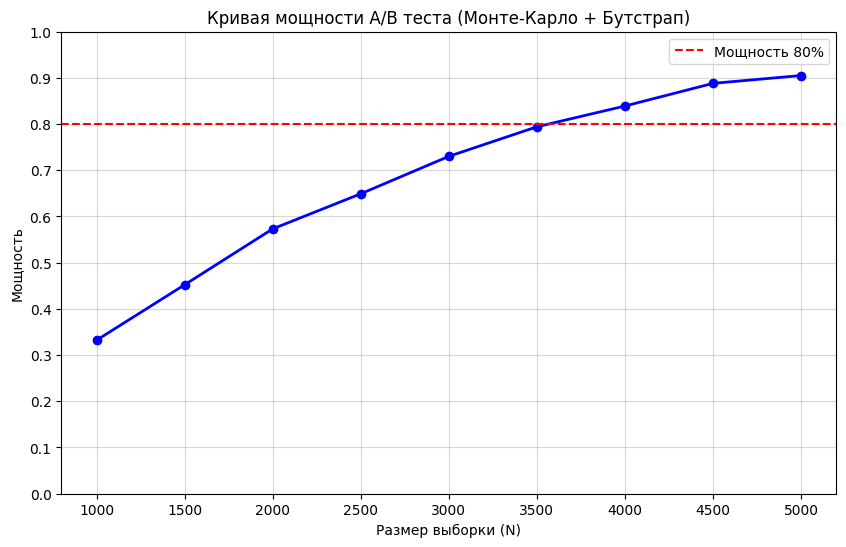

In [19]:
# сплитование юзеров (контрольная группа - 90%)
def hash_split(userid, salt, percent=90):
    str2hash = str(userid) + str(salt)
    result = int(hashlib.md5(str2hash.encode()).hexdigest(), 16) % 100
    return 1 if result >= percent else 0 # возвращаем 1 для 'test' и 0 для 'control'

# функция для Пуассоновского бутстрапа
def poisson_bootstrap_test(clicks_test, views_test, clicks_control, views_control, B=1000):
    n_test = len(clicks_test)
    n_control = len(clicks_control)

    # веса из распределения Пуассона (лямбда=1)
    weights_test = np.random.poisson(1, size=(B, n_test))
    weights_control = np.random.poisson(1, size=(B, n_control))

    # бутстрапированные CTR
    boot_ctr_test = np.sum(weights_test * clicks_test.values, axis=1) / np.sum(weights_test * views_test.values, axis=1)
    boot_ctr_control = np.sum(weights_control * clicks_control.values, axis=1) / np.sum(weights_control * views_control.values, axis=1)
    boot_diff = boot_ctr_test - boot_ctr_control

    # нижняя граница доверительного 95% интервала
    ci_lower = np.percentile(boot_diff, 2.5)

    # 1, если успешный тест
    return 1 if ci_lower > 0 else 0


# цикл симуляций
def run_power_analysis(user_data, n_values, mc_simulations=1000, bootstrap_iterations=1000):
    powers = []
    for n in n_values:
        significant_results = 0
        for sim in range(mc_simulations):

            # рандомная выборка размера n из исторических данных
            sample_df = user_data.sample(n=n, replace=False)

            # сплитование, соль - номер симуляции
            sample_df['is_test'] = sample_df['user_id'].apply(lambda x: hash_split(x, salt=f'salt_{sim}'))

            # добавляем 10% к кликам в тестовой группе (условная мат модель)
            sample_df['simulated_clicks'] = np.where(
                sample_df['is_test'] == 1,
                sample_df['total_clicks'] * 1.1,
                sample_df['total_clicks']
            )

            # разделяем на массивы для бутстрапа
            test_group = sample_df[sample_df['is_test'] == 1]
            control_group = sample_df[sample_df['is_test'] == 0]

            # защита: может никто не попасть в тестовую группу
            if test_group['total_views'].sum() == 0 or control_group['total_views'].sum() == 0:
                continue

            # бутстрап и проверка значимости
            is_significant = poisson_bootstrap_test(
                clicks_test=test_group['simulated_clicks'],
                views_test=test_group['total_views'],
                clicks_control=control_group['total_clicks'],
                views_control=control_group['total_views'],
                B=bootstrap_iterations
            )
            significant_results += is_significant

        # мощность = доля успешных тестов
        power = significant_results / mc_simulations
        powers.append(power)
    return powers

# берем n от 1000 до 5000 с шагом 500
n_values = range(1000, 5001, 500)
powers = run_power_analysis(user_data, n_values, mc_simulations=1000, bootstrap_iterations=1000)


# график
plt.figure(figsize=(10, 6))
plt.plot(n_values, powers, marker='o', linewidth=2, color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='Мощность 80%')
plt.title('Кривая мощности A/B теста (Монте-Карло + Бутстрап)')
plt.xlabel('Размер выборки (N)')
plt.ylabel('Мощность')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

Требуемый общий размер выборки - примерно 3500 пользователей

### 1.4. Бакетизация

Расчет необходимого размера выборки производится через симуляции Монте-Карло.

1. Симуляции проводятся для разных размеров выборки (берем n от 1000 до 7000 с шагом 500)

2. Берется случайная выборка размера n из исторических данных

    2.1. Случайное сплитование пользователей в контрольную и тестовую группу (в контроль попадает 90%)

    2.2. Добавляем эффект в тестовую группу: для увеличения CTR на 10% умножаем количество кликов у пользователя на 1,1

    2.3. Бакетизация:

    - присваиваем каждому пользователю случайный номер бакета (от 1 до 50, по прошлым тестам видим, что в тестовой группе может быть всего 300 с небольшим пользователей - поэтому 200 бакетов выглядит многовато)
    - в тесте и контроле получилось по 50 бакетов, в каждом бакете считаем CTR
    - оценка значимости разницы между тестом и контролем: t-test

3. По итогам проведения (например) 1000 симуляций рассчитываем статистическую мощность = значимые тесты / всего тестов

4. Для каждой n получили статистическую мощность - строим график, оцениваем, при какой n мощность становится более 80%

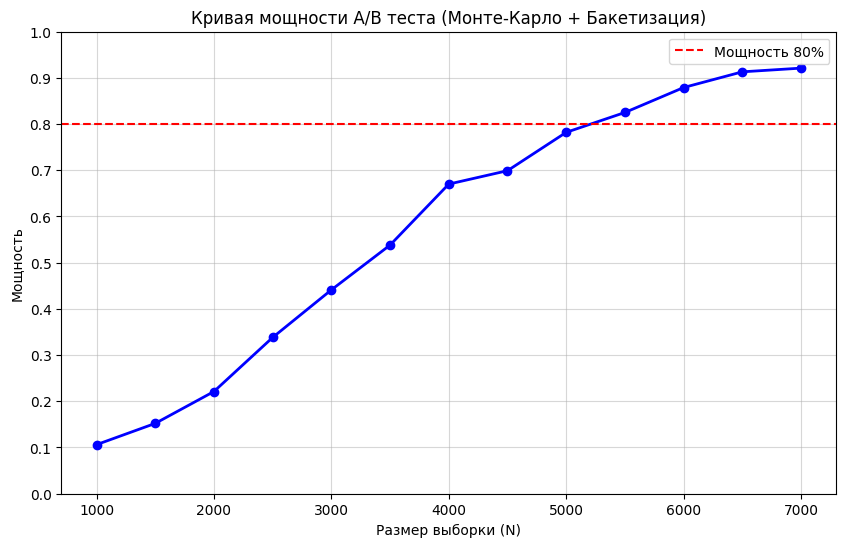

In [20]:
# сплитование юзеров (контрольная группа - 90%)
def hash_split(userid, salt, percent=90):
    str2hash = str(userid) + str(salt)
    result = int(hashlib.md5(str2hash.encode()).hexdigest(), 16) % 100
    return 1 if result >= percent else 0 # возвращаем 1 для 'test' и 0 для 'control'

# функция для бакетизации и t-теста
def bucketized_ab_test(clicks_test, views_test, clicks_control, views_control, num_buckets=50):

    # случайное распределение пользователей по бакетам
    buckets_test = np.random.randint(0, num_buckets, size=len(clicks_test))
    buckets_control = np.random.randint(0, num_buckets, size=len(clicks_control))

    # агрегируем данные для теста
    df_test = pd.DataFrame({'clicks': clicks_test, 'views': views_test, 'bucket': buckets_test})
    test_agg = df_test.groupby('bucket')[['clicks', 'views']].sum()
    test_agg = test_agg[test_agg['views'] > 0] # защита от деления на 0
    test_ctr = test_agg['clicks'] / test_agg['views']

    # агрегируем данные для контроля
    df_control = pd.DataFrame({'clicks': clicks_control, 'views': views_control, 'bucket': buckets_control})
    control_agg = df_control.groupby('bucket')[['clicks', 'views']].sum()
    control_agg = control_agg[control_agg['views'] > 0] # защита от деления на 0
    control_ctr = control_agg['clicks'] / control_agg['views']

    # Welch t-test
    stat, p_value = stats.ttest_ind(test_ctr, control_ctr, equal_var=False)

    # 1, если успешный тест (p-value < 0.05 и эффект положительный)
    return 1 if p_value < 0.05 and test_ctr.mean() > control_ctr.mean() else 0


# цикл симуляций
def run_power_analysis(user_data, n_values, mc_simulations=1000, num_buckets=50):
    powers = []
    for n in n_values:
        significant_results = 0
        for sim in range(mc_simulations):

            # рандомная выборка размера n из исторических данных
            sample_df = user_data.sample(n=n, replace=False)

            # сплитование, соль - номер симуляции
            sample_df['is_test'] = sample_df['user_id'].apply(lambda x: hash_split(x, salt=f'salt_{sim}'))

            # добавляем 10% к кликам в тестовой группе (условная мат модель)
            sample_df['simulated_clicks'] = np.where(
                sample_df['is_test'] == 1,
                sample_df['total_clicks'] * 1.1,
                sample_df['total_clicks']
            )
            # разделяем на массивы для бакетизации
            test_group = sample_df[sample_df['is_test'] == 1]
            control_group = sample_df[sample_df['is_test'] == 0]

            # защита: может никто не попасть в тестовую группу (особенно на малых выборках)
            if test_group['total_views'].sum() == 0 or control_group['total_views'].sum() == 0:
                continue

            # бакетизация и проверка значимости
            is_significant = bucketized_ab_test(
                clicks_test=test_group['simulated_clicks'].values,
                views_test=test_group['total_views'].values,
                clicks_control=control_group['total_clicks'].values,
                views_control=control_group['total_views'].values,
                num_buckets=num_buckets
            )
            significant_results += is_significant

        # мощность = доля успешных тестов
        power = significant_results / mc_simulations
        powers.append(power)

    return powers

# берем n от 1000 до 7000 с шагом 500
n_values = range(1000, 7001, 500)
powers = run_power_analysis(user_data, n_values, mc_simulations=1000, num_buckets=50)


# график
plt.figure(figsize=(10, 6))
plt.plot(n_values, powers, marker='o', linewidth=2, color='b')
plt.axhline(y=0.8, color='r', linestyle='--', label='Мощность 80%')
plt.title('Кривая мощности A/B теста (Монте-Карло + Бакетизация)')
plt.xlabel('Размер выборки (N)')
plt.ylabel('Мощность')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

Для использования бакетизации требуется больше пользователей, около 5500. В этой симуляции бакетизация показала меньшую мощность. Результат зависит от количества бакетов, их наполненности и случайного распределения пользователей.

## Результаты А/В теста

### 2.1. Дельта-метод

Используется обычный z-тест, но формула дисперсии корректируется с учетом зависимости числителя и знаменателя:
$CTR_{gr}=R_{gr}=\frac{\sum_N{c}}{\sum_N{v}}=\frac{\bar c}{\bar v}$

$Var(R_{gr})=\frac{1}{N} \cdot \frac{1}{\bar v^2} \cdot (Var(\bar c) - 2 \cdot R \cdot Cov(c,v)+R^2 \cdot Var(\bar v))$

$Z=\frac{R_B-R_A}{\sqrt{Var(R_B)+Var(R_A)}}$

In [21]:
df = pd.read_csv('results.csv')

group_a = df[df['group'] == 'A']
group_b = df[df['group'] == 'B']

def get_group_stats(group_data):
    n = len(group_data)
    clicks = group_data['clicks']
    views = group_data['views']

    mean_clicks = clicks.mean()
    mean_views = views.mean()

    ctr = mean_clicks / mean_views

    var_clicks = clicks.var()
    var_views = views.var()
    cov = clicks.cov(views)

    var_ctr = (1/mean_views**2)*(var_clicks - 2*ctr*cov + (ctr**2)*var_views)/n

    return ctr, var_ctr

# статистики для контрольной и тестовой групп
ctr_a, var_ctr_a = get_group_stats(group_a)
ctr_b, var_ctr_b = get_group_stats(group_b)

z_stat = (ctr_b - ctr_a)/np.sqrt(var_ctr_a + var_ctr_b)

# p-value для двустороннего теста
p_value = 2 * stats.norm.sf(abs(z_stat))

print(f'CTR контрольной группы: {ctr_a:.2%}')
print(f'CTR тестовой группы: {ctr_b:.2%}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('Разница статистически значима')
else:
    print('Разница статистически не значима')


CTR контрольной группы: 31.04%
CTR тестовой группы: 32.66%
P-value: 0.0915
Разница статистически не значима


### 2.2. Линеаризация

Линеаризованная метрика: для каждого пользователя рассчитываем

$lc=c-R \cdot v$, где $R=\frac{\sum^N_i{c}}{\sum^N_i{v}}$

Потом сравниваем контрольный и тестовый массивы $L_A$ и $L_B$, используя обычный Welch t-test

In [22]:
# коэффициент R (CTR контрольной группы)
R = group_a['clicks'].sum()/group_a['views'].sum()

# массив линеаризованных метрик для групп
lin_a = group_a['clicks'] - R*group_a['views']
lin_b = group_b['clicks'] - R*group_b['views']

ctr_a = R
ctr_b = group_b['clicks'].sum()/group_b['views'].sum()

# t-test
stat, p_value = stats.ttest_ind(lin_b, lin_a, equal_var=False)

print(f'CTR контрольной группы: {ctr_a:.2%}')
print(f'CTR тестовой группы: {ctr_b:.2%}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('Разница статистически значима')
else:
    print('Разница статистически не значима')


CTR контрольной группы: 31.04%
CTR тестовой группы: 32.66%
P-value: 0.1107
Разница статистически не значима


### 2.3. Бутстрап



In [23]:
clicks_test = group_b['clicks']
clicks_control = group_a['clicks']
views_test = group_b['views']
views_control = group_a['views']

ctr_test = clicks_test.sum()/views_test.sum()
ctr_control = clicks_control.sum()/views_control.sum()

n_test = len(clicks_test)
n_control = len(clicks_control)

B=10000 #итерации бутстрапа

# веса из распределения Пуассона (лямбда=1)
weights_test = np.random.poisson(1, size=(B, n_test))
weights_control = np.random.poisson(1, size=(B, n_control))

# бутстрапированные CTR
boot_ctr_test = np.sum(weights_test * clicks_test.values, axis=1) / np.sum(weights_test * views_test.values, axis=1)
boot_ctr_control = np.sum(weights_control * clicks_control.values, axis=1) / np.sum(weights_control * views_control.values, axis=1)

# массив разниц между тестом и контролем
boot_diff = boot_ctr_test - boot_ctr_control

# доля итераций, где разница <= 0 (тест хуже или равен контролю)
prob_less_or_equal_zero = np.mean(boot_diff <= 0)

# доля итераций, где разница >= 0 (тест лучше или равен контролю)
prob_greater_or_equal_zero = np.mean(boot_diff >= 0)

# двусторонний p-value (удвоенный минимум из этих двух долей)
p_value = 2 * min(prob_less_or_equal_zero, prob_greater_or_equal_zero)

p_value = min(p_value, 1.0)

print(f'CTR контрольной группы: {ctr_control:.2%}')
print(f'CTR тестовой группы: {ctr_test:.2%}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('Разница статистически значима')
else:
    print('Разница статистически не значима')

CTR контрольной группы: 31.04%
CTR тестовой группы: 32.66%
P-value: 0.0976
Разница статистически не значима


### 2.4. Бакетизация

In [24]:
num_buckets = 50

# случайное распределение пользователей по бакетам
buckets_test = np.random.randint(0, num_buckets, size=len(clicks_test))
buckets_control = np.random.randint(0, num_buckets, size=len(clicks_control))

# агрегируем данные для теста
df_test = pd.DataFrame({'clicks': clicks_test, 'views': views_test, 'bucket': buckets_test})
test_agg = df_test.groupby('bucket')[['clicks', 'views']].sum()
test_agg = test_agg[test_agg['views'] > 0] # защита от деления на 0
test_ctr = test_agg['clicks'] / test_agg['views']

# агрегируем данные для контроля
df_control = pd.DataFrame({'clicks': clicks_control, 'views': views_control, 'bucket': buckets_control})
control_agg = df_control.groupby('bucket')[['clicks', 'views']].sum()
control_agg = control_agg[control_agg['views'] > 0] # защита от деления на 0
control_ctr = control_agg['clicks'] / control_agg['views']

# Welch t-test
stat, p_value = stats.ttest_ind(test_ctr, control_ctr, equal_var=False)

print(f'CTR контрольной группы: {ctr_control:.2%}')
print(f'CTR тестовой группы: {ctr_test:.2%}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('Разница статистически значима')
else:
    print('Разница статистически не значима')

CTR контрольной группы: 31.04%
CTR тестовой группы: 32.66%
P-value: 0.4088
Разница статистически не значима


Все методы показали, что полученная в тесте разница между тестовой и контрольной группой не значима.